Here we investigate the consequences of the severity screening threshold on our exceedance function. We consider the following situations:
1. Dropping data points below a screening threshold and fitting without acknowledging it.
2. Acknowledge the screening threshold as you fit.
3. Don't drop and fit.
4. With and without truncation of the distribution at the largest data point.

We will try both with the Marani et al. dataset and with synthetic data.

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
from scipy.stats import genpareto

In [2]:
# Load data
marani_raw = pd.read_excel("../../data/raw/epidemics_marani_240816.xlsx")
marani_raw = marani_raw[marani_raw['year_start'].between(1600, 1945)]
marani_raw = marani_raw[marani_raw['death_thousand'] >= 0]
marani_raw['intensity'] = marani_raw['severity_perthousand'] / marani_raw['duration']

In [7]:
# Constants
MU_PRIME = 1e-3  # Deaths / thousand / year units
THRESH = MU_PRIME * 1e2

Text(0.5, 1.0, 'Empirical Exceedance Distribution')

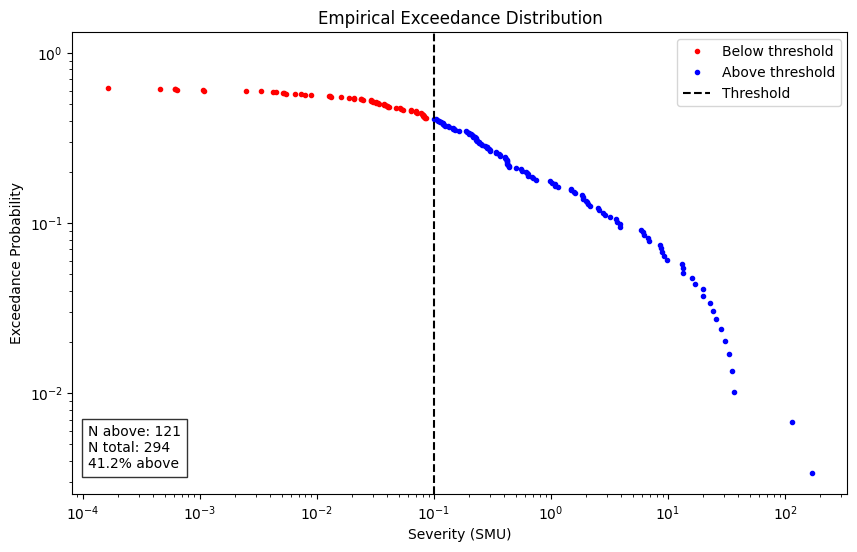

In [8]:
# Calculate number and percentage above threshold
# Calculate stats
n_above = len(marani_raw[marani_raw['severity_smu'] >= THRESH])
n_total = len(marani_raw)
pct_above = n_above * 100 / n_total

# Plot empirical exceedance
plt.figure(figsize=(10,6))
sorted_data = np.sort(marani_raw['severity_smu'].values)
emp_exceed = 1 - np.arange(1, len(sorted_data) + 1) / (len(sorted_data) + 1)

plt.plot(sorted_data[sorted_data < THRESH], 
         emp_exceed[sorted_data < THRESH],
         'r.', label='Below threshold')
plt.plot(sorted_data[sorted_data >= THRESH],
         emp_exceed[sorted_data >= THRESH], 
         'b.', label='Above threshold')
plt.axvline(x=THRESH, color='k', linestyle='--', label='Threshold')

# Add stats text
plt.text(0.02, 0.15, 
         f'N above: {n_above}\nN total: {n_total}\n{pct_above:.1f}% above',
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.8))

plt.xscale('log')
plt.yscale('log')
plt.ylabel('Exceedance Probability')
plt.xlabel('Severity (SMU)')
plt.legend()
plt.title('Empirical Exceedance Distribution')

In [ ]:
def fit_distributions(data, loc_param, screen_thresh=None):
    """
    Fit GPD distributions to data with different threshold handling approaches.
    
    Args:
        data (pd.Series): Data to fit
        screen_thresh (float): Screening threshold for data filtering
        loc_param (float): Location parameter for GPD fit. If None, uses screen_thresh
        
    Returns:
        tuple: Fitted GPD parameters (shape, location, scale)
    """
    if screen_thresh is None:
      screen_thresh = loc_param
    else:
      assert(screen_thresh >= loc_param)

    filtered_data = data[data >= screen_thresh]
    return genpareto.fit(filtered_data, floc=loc_param)

In [33]:
def plot_exceedance_subplots(data, loc_param, screen_thresh):
    """
    Plot exceedance probability curves with given parameters in a two-panel subplot.
    
    Args:
        data (pd.Series): Original data
        loc_param (float): Location parameter for GPD fit
        screen_thresh (float): Screening threshold for data filtering
    """
    # Fit distributions with parameters
    params_no_ack = fit_distributions(data, loc_param)
    params_with_ack = fit_distributions(data, loc_param, screen_thresh=screen_thresh)
    
    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True, sharex=True)
    
    # Get common x range for all plots
    x = np.logspace(-4, 3, 10000)
    
    params_list = [params_no_ack, params_with_ack]
    screen_thresholds = [loc_param, screen_thresh]
    labels = ['Loc = Screen', 'Loc ≠ Screen']
    
    for ax, params, screen_thresh, label in zip(axes, params_list, screen_thresholds, labels):
        # Plot empirical exceedance for filtered data
        filtered_data = data[data >= screen_thresh]
        sorted_data = np.sort(filtered_data)
        emp_exceed = 1 - np.arange(1, len(filtered_data) + 1) / (len(filtered_data) + 1)
        ax.plot(sorted_data, emp_exceed, 'k.', label='Empirical', alpha=0.5)
        
        # Plot fitted curve
        exceed_prob = 1 - genpareto.cdf(x, *params)
        ax.plot(x, exceed_prob, label=f'Fitted ({label})')
        
        # Add threshold and location parameter lines
        ax.axvline(x=screen_thresh, color='r', linestyle='--', 
                  label='Screening Threshold', alpha=0.5)
        ax.axvline(x=params[1], color='g', linestyle=':', 
                  label=f'Location Parameter ({params[1]:.2f})', alpha=0.5)
        
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_ylabel('Exceedance Probability' if ax == axes[0] else '')
        ax.set_xlabel('Severity (SMU)')
        ax.set_title(label)
        ax.grid(True)
        ax.legend()
    
    plt.tight_layout()
    plt.show()


# Create interactive widgets
loc_slider = widgets.FloatLogSlider(
    value=0.1,
    base=10,
    min=-4, # min exponent of base
    max=1,  # max exponent of base
    step=0.1,
    description='Location Parameter:',
    continuous_update=False
)

screen_slider = widgets.FloatLogSlider(
    value=1.0,
    base=10,
    min=-4,
    max=1,
    step=0.1,
    description='Screen Threshold:',
    continuous_update=False
)

# Functions to update plots
def update_subplots(loc_param, screen_thresh):
    if screen_thresh < loc_param:
        print("Warning: Screen threshold must be >= location parameter")
        return
    plot_exceedance_subplots(marani_raw['severity_smu'], loc_param, screen_thresh)


# Create interactive plots
print("Subplot View:")
widgets.interactive(update_subplots, 
                   loc_param=loc_slider,
                   screen_thresh=screen_slider)


Subplot View:


interactive(children=(FloatLogSlider(value=0.1, continuous_update=False, description='Location Parameter:', ma…

In [31]:
def plot_comparison(data, loc_param, screen_thresh):
    """
    Plot a single comparison of exceedance curves, accounting for annual pandemic arrival rates.
    
    Args:
        data (pd.Series): Original data from 1600-1945
        loc_param (float): Location parameter for GPD fit
        screen_thresh (float): Screening threshold for data filtering
    """
    # Calculate observation period and annual rate
    start_year = 1600
    end_year = 1945
    n_years = end_year - start_year + 1
    
    # Fit distributions with parameters
    params_loc_screen = fit_distributions(data, loc_param)
    params_high_screen = fit_distributions(data, loc_param, screen_thresh=screen_thresh)
    
    plt.figure(figsize=(10,6))
    ax = plt.gca()

    # Plot empirical data with annual rate adjustment
    filtered_data = data[data >= loc_param]
    annual_rate_loc_screen = len(filtered_data) / n_years
    annual_rate_high_screen = len(filtered_data[filtered_data >= screen_thresh]) / n_years
    
    sorted_data = np.sort(filtered_data)
    emp_exceed = (1 - np.arange(1, len(filtered_data) + 1) / (len(filtered_data) + 1)) * annual_rate_loc_screen
    ax.plot(sorted_data, emp_exceed, 'k.', label='Empirical', alpha=0.5)

    # Create x values for fitted curves
    x = np.logspace(np.log10(loc_param), np.log10(max(data)*1.1), 1000)

    # Plot both fitted curves with annual rate adjustment
    exceed_prob_loc_screen = (1 - genpareto.cdf(x, *params_loc_screen)) * annual_rate_loc_screen
    exceed_prob_high_screen = (1 - genpareto.cdf(x, *params_high_screen)) * annual_rate_high_screen
    ax.plot(x, exceed_prob_loc_screen, label='Loc = Screen')
    ax.plot(x, exceed_prob_high_screen, label='Loc ≠ Screen')

    # Add vertical lines for thresholds and max observation
    ax.axvline(x=loc_param, color='g', linestyle=':', 
               label=f'Location Parameter ({loc_param:.2f})', alpha=0.5)
    ax.axvline(x=screen_thresh, color='r', linestyle='--', 
               label='Screening Threshold', alpha=0.5)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel('Annual Exceedance Probability')
    ax.set_xlabel('Severity (SMU)')
    ax.set_title('Direct Comparison of Different Threshold Approaches\n(Adjusted for Annual Arrival Rate)')
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()

def update_comparison(loc_param, screen_thresh):
    if screen_thresh < loc_param:
        print("Warning: Screen threshold must be >= location parameter")
        return
    plot_comparison(marani_raw['severity_smu'], loc_param, screen_thresh)


print("\nComparison View:")
widgets.interactive(update_comparison,
                   loc_param=loc_slider,
                   screen_thresh=screen_slider)



Comparison View:


interactive(children=(FloatLogSlider(value=0.05011872336272725, continuous_update=False, description='Location…